# Seguro agrícola indexado – Panel climático Ricaurte (Moniquirá, Boyacá) y La Unión (Nariño)

**Objetivo:**  
Construir un panel mensual de variables climáticas (temperatura, humedad, precipitación y radiación) para dos municipios cafeteros de Colombia, usando datos de reanálisis ERA5 (Copernicus), como insumo para el diseño de un seguro agrícola indexado para café.

**Municipios:**
- Vereda Ricaurte – Municipio de Moniquirá, Boyacá
- Municipio de La Unión, Nariño


In [4]:
import os
import glob
import zipfile
import cdsapi
import xarray as xr
import pandas as pd
import numpy as np

# Opcional: ver todas las columnas al hacer head()
pd.set_option("display.max_columns", None)


In [6]:
# ============================
# CONFIGURACIÓN RICAURTE–MONIQUÍRA
# ============================

BASE_DIR_R = "/Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca"
os.makedirs(BASE_DIR_R, exist_ok=True)

# Coordenadas vereda Ricaurte (municipio de Moniquirá)
lat_ricaurte = 5.87444
lon_ricaurte = -73.57170

delta = 0.25
area_ricaurte = [
    lat_ricaurte + delta,   # North
    lon_ricaurte - delta,   # West
    lat_ricaurte - delta,   # South
    lon_ricaurte + delta    # East
]

c = cdsapi.Client()

anios = list(range(2015, 2025))  # 2015–2024
panel_ricaurte = []

for anio in anios:
    print(f"\n=== PROCESANDO AÑO {anio} (RICAURTE–MONIQUÍRA) ===")

    zip_path = os.path.join(BASE_DIR_R, f"era5_ricaurte_moniquira_{anio}_full.nc")

    if not os.path.exists(zip_path):
        print(f"Descargando ERA5 mensual {anio} para Ricaurte–Moniquirá...")
        _ = c.retrieve(
            "reanalysis-era5-single-levels-monthly-means",
            {
                "product_type": "monthly_averaged_reanalysis",
                "variable": [
                    "2m_temperature",
                    "2m_dewpoint_temperature",
                    "total_precipitation",
                    "surface_solar_radiation_downwards",
                ],
                "year": str(anio),
                "month": [f"{m:02d}" for m in range(1, 13)],
                "time": "00:00",
                "area": area_ricaurte,
                "format": "netcdf",
            },
            zip_path,
        )
        print("Descarga terminada.")
    else:
        print(f"Archivo ya existe, se omite descarga: {zip_path}")

    # Descomprimir
    unzipped_dir = os.path.join(BASE_DIR_R, f"unzipped_{anio}")
    os.makedirs(unzipped_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(unzipped_dir)

    archivos_nc = glob.glob(os.path.join(unzipped_dir, "*.nc"))
    avgua_path = [f for f in archivos_nc if "avgua" in f][0]  # t2m, d2m
    avgad_path = [f for f in archivos_nc if "avgad" in f][0]  # tp, ssrd

    ds_t = xr.open_dataset(avgua_path)
    ds_p = xr.open_dataset(avgad_path)

    p_t = ds_t.sel(latitude=lat_ricaurte, longitude=lon_ricaurte, method="nearest")
    p_p = ds_p.sel(latitude=lat_ricaurte, longitude=lon_ricaurte, method="nearest")

    ds_comb = xr.merge([p_t[["t2m", "d2m"]], p_p[["tp", "ssrd"]]])
    df = ds_comb.to_dataframe().reset_index()

    df["month"] = df["valid_time"].dt.to_period("M").dt.to_timestamp()

    df_monthly = pd.DataFrame()
    df_monthly[["t2m", "d2m"]] = df.groupby("month")[["t2m", "d2m"]].first()
    df_monthly[["tp", "ssrd"]] = df.groupby("month")[["tp", "ssrd"]].sum()
    df_monthly = df_monthly.reset_index().rename(columns={"month": "valid_time"})

    df_monthly["t2m_c"]   = df_monthly["t2m"] - 273.15
    df_monthly["d2m_c"]   = df_monthly["d2m"] - 273.15
    df_monthly["tp_mm"]   = df_monthly["tp"] * 1000.0
    df_monthly["ssrd_MJ"] = df_monthly["ssrd"] / 1e6

    t = df_monthly["t2m_c"]
    d = df_monthly["d2m_c"]
    df_monthly["RH"] = 100 * np.exp(
        (17.625 * d) / (243.04 + d) - (17.625 * t) / (243.04 + t)
    )

    df_monthly["year"] = anio

    df_monthly = df_monthly[[
        "valid_time", "year", "t2m_c", "d2m_c", "RH", "tp_mm", "ssrd_MJ"
    ]]

    panel_ricaurte.append(df_monthly)

df_ricaurte_panel = pd.concat(panel_ricaurte).sort_values("valid_time").reset_index(drop=True)

csv_ricaurte = os.path.join(BASE_DIR_R, "ricaurte_moniquira_panel_2015_2024.csv")
df_ricaurte_panel.to_csv(csv_ricaurte, index=False)

print("\n✅ Panel Ricaurte–Moniquirá guardado en:")
print(csv_ricaurte)

df_ricaurte_panel.head()



=== PROCESANDO AÑO 2015 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omite descarga: /Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/era5_ricaurte_moniquira_2015_full.nc

=== PROCESANDO AÑO 2016 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omite descarga: /Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/era5_ricaurte_moniquira_2016_full.nc

=== PROCESANDO AÑO 2017 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omite descarga: /Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/era5_ricaurte_moniquira_2017_full.nc

=== PROCESANDO AÑO 2018 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omite descarga: /Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/era5_ricaurte_moniquira_2018_full.nc

=== PROCESANDO AÑO 2019 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omite descarga: /Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/era5_ricaurte_moniquira_2019_full.nc

=== PROCESANDO AÑO 2020 (RICAURTE–MONIQUÍRA) ===
Archivo ya existe, se omi

,valid_time,year,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ
0,2015-01-01,2015,15.587555,11.431305,76.298485,3.893211,18.935520
1,2015-02-01,2015,15.988922,12.668121,80.673370,5.935572,18.381824
2,2015-03-01,2015,16.029449,13.143219,83.003944,7.540397,18.318607
3,2015-04-01,2015,16.369537,13.250641,81.795288,11.235106,17.785149
4,2015-05-01,2015,16.640778,12.795807,78.042809,8.861885,18.225807


### 📌 Nota sobre la obtención de datos para La Unión (Nariño)

Los datos climáticos de **La Unión (Nariño)** correspondientes al periodo **2015–2024** ya habían sido descargados previamente desde otro notebook del mismo proyecto. Sin embargo, se incluye aquí este script como **anexo técnico**, con el fin de documentar de manera transparente la metodología utilizada y asegurar la trazabilidad completa del proceso de obtención de datos.

Los datos fueron obtenidos mediante la **API oficial del Copernicus Climate Data Store (CDS)** utilizando el dataset:

**`reanalysis-era5-single-levels-monthly-means`**

Este dataset, producido por el **ECMWF**, es una fuente científica de alta calidad que garantiza:

- Consistencia y continuidad temporal.  
- Homogeneidad en los métodos de recopilación.  
- Validación conforme a estándares internacionales (CF-1.7).  
- Resolución espacial adecuada para estudios regionales.  

Gracias a estas características, los datos descargados cumplen con los criterios de **fiabilidad**, **rigurosidad** y **calidad** necesarios para un estudio técnico como el del **modelo analítico para un seguro agrícola indexado**.

La inclusión de esta sección permite mantener la trazabilidad entre ambos municipios analizados y asegura que la calidad de los datos utilizados en el estudio es consistente y adecuada.


In [8]:
ruta_union = "/Users/sergioandresgarciablanco/era5_puntos/la_union_narino/la_union_narino_panel_2015_2024.csv"
df_union_panel = pd.read_csv(ruta_union)

df_union_panel.head()


,valid_time,year,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ
0,2015-01-01,2015,18.629180,15.431305,81.665650,12.493048,18.585024
1,2015-02-01,2015,18.771759,15.951813,83.682144,10.392971,18.140713
2,2015-03-01,2015,18.606598,16.152740,85.641930,18.666845,17.384708
3,2015-04-01,2015,19.077911,16.039581,82.559460,17.487564,18.110704
4,2015-05-01,2015,19.096588,15.633209,80.349030,13.599671,17.771502


In [10]:
# Asegurarse de tener cargado también el panel de Ricaurte desde CSV
ruta_ricaurte_csv = "/Users/sergioandresgarciablanco/era5_puntos/ricaurte_boyaca/ricaurte_moniquira_panel_2015_2024.csv"
df_ricaurte_panel = pd.read_csv(ruta_ricaurte_csv)

df_ricaurte_panel["municipio"] = "Ricaurte-Moniquira"
df_union_panel["municipio"] = "La Union-Narino"

df_comb = pd.concat([df_ricaurte_panel, df_union_panel], ignore_index=True)
df_comb = df_comb.sort_values(["valid_time", "municipio"]).reset_index(drop=True)

df_comb.head()


,valid_time,year,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ,municipio
0,2015-01-01,2015,18.629180,15.431305,81.665650,12.493048,18.585024,La Union-Narino
1,2015-01-01,2015,15.587555,11.431305,76.298485,3.893211,18.935520,Ricaurte-Moniquira
2,2015-02-01,2015,18.771759,15.951813,83.682144,10.392971,18.140713,La Union-Narino
3,2015-02-01,2015,15.988922,12.668121,80.673370,5.935572,18.381824,Ricaurte-Moniquira
4,2015-03-01,2015,18.606598,16.152740,85.641930,18.666845,17.384708,La Union-Narino


In [18]:
ruta_comb = "/Users/sergioandresgarciablanco/final_era5_puntos_ricaurte_la_union_2015_2024.csv"
df_comb.to_csv(ruta_comb, index=False)
print("✅ Panel combinado guardado en:", ruta_comb)


✅ Panel combinado guardado en: /Users/sergioandresgarciablanco/final_era5_puntos_ricaurte_la_union_2015_2024.csv


In [29]:
# === 1. ESTADÍSTICAS DESCRIPTIVAS ===

variables = ["t2m_c", "d2m_c", "RH", "tp_mm", "ssrd_MJ"]

print("=== Ricaurte – Moniquirá (Boyacá) ===")
display(df_ricaurte_panel[variables].describe())

print("=== La Unión (Nariño) ===")
display(df_union_panel[variables].describe())

=== Ricaurte – Moniquirá (Boyacá) ===


,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,16.078521,12.759771,80.810768,7.503733,18.056248
std,0.572243,0.804684,4.399132,2.693271,1.340209
min,14.957428,10.750397,67.555710,1.060260,14.777744
25%,15.681793,12.173126,77.299312,5.691824,16.972862
50%,16.021760,12.771881,81.765767,7.696678,17.932288
75%,16.494293,13.356720,84.039385,9.356489,18.944860
max,17.466950,14.581207,88.394394,14.612894,21.751600


=== La Unión (Nariño) ===


,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,19.015868,15.447514,80.139748,13.324099,17.927455
std,0.650599,1.124760,7.280567,5.000897,1.439362
min,17.640778,10.849396,54.050530,0.884152,15.406103
25%,18.528748,14.940368,76.276378,9.922538,16.857001
50%,19.009247,15.805877,82.640842,13.918771,17.655655
75%,19.508148,16.218445,85.294969,17.286894,18.865513
max,20.646149,17.066070,89.255690,22.793050,21.354960


In [35]:
# === 2. OUTLIERS POR IQR ===

def detectar_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))]
    return outliers

print("=== Outliers – Ricaurte ===")
display(detectar_outliers(df_ricaurte_panel[variables]).dropna(how="all"))

print("=== Outliers – La Unión ===")
display(detectar_outliers(df_union_panel[variables]).dropna(how="all"))


=== Outliers – Ricaurte ===


,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ


=== Outliers – La Unión ===


,t2m_c,d2m_c,RH,tp_mm,ssrd_MJ
43,NaN,12.622345,62.172222,NaN,NaN
55,NaN,10.849396,54.050530,NaN,NaN
115,NaN,12.840607,NaN,NaN,NaN


In [39]:
# === FUNCIONES DE GRÁFICAS ===

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --- Boxplots ---
def boxplots(df, titulo):
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df[["t2m_c","d2m_c","RH","tp_mm","ssrd_MJ"]])
    plt.title(f"Boxplots – {titulo}")
    plt.xticks(rotation=45)
    plt.show()

# --- Histogramas ---
def histogramas(df, titulo):
    df[["t2m_c","d2m_c","RH","tp_mm","ssrd_MJ"]].hist(figsize=(12,8), bins=10)
    plt.suptitle(f"Histogramas – {titulo}", fontsize=15)
    plt.show()

# --- Series de tiempo ---
def series_tiempo(df, titulo):
    plt.figure(figsize=(14,5))
    plt.plot(df["valid_time"], df["t2m_c"], label="Temp (°C)")
    plt.plot(df["valid_time"], df["RH"], label="Humedad (%)")
    plt.title(f"Serie de tiempo – {titulo}")
    plt.legend()
    plt.show()



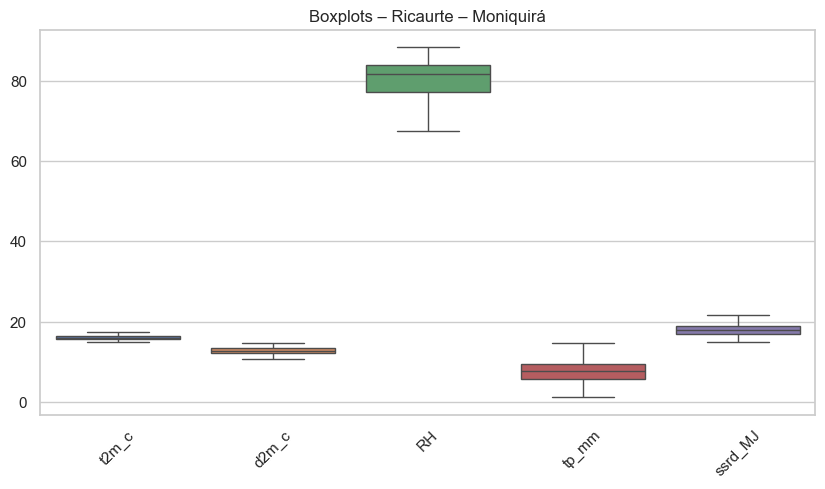

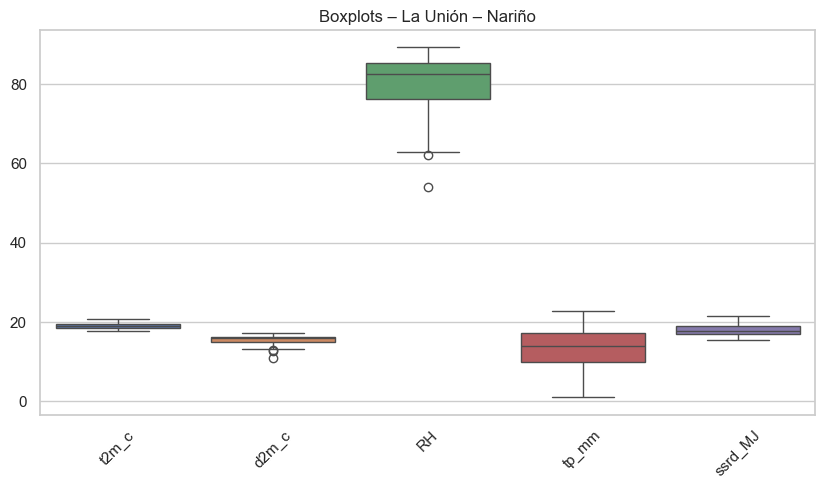

In [47]:
# === 3.1 BOXPLOTS ===
boxplots(df_ricaurte_panel, "Ricaurte – Moniquirá")
boxplots(df_union_panel, "La Unión – Nariño")


In [49]:
# Verificación de datos faltantes
df_comb.isna().sum()


valid_time    0
year          0
t2m_c         0
d2m_c         0
RH            0
tp_mm         0
ssrd_MJ       0
municipio     0
dtype: int64

## Conclusiones del análisis descriptivo

1. **No se identificaron datos faltantes en ninguno de los dos paneles** (Ricaurte–Moniquirá y La Unión), lo cual indica que la descarga, consolidación y conversión de las variables climáticas se realizó correctamente. Esto garantiza confiabilidad para los cálculos y comparaciones posteriores.

2. En cuanto a **temperatura media (t2m_c)**, se observa una diferencia estructural:  
   - *Ricaurte–Moniquirá*: **16.07 °C**  
   - *La Unión*: **19.02 °C**  
   Esto confirma que La Unión tiene condiciones notablemente más cálidas, coherentes con su menor elevación sobre el nivel del mar.

3. Las medidas de **humedad relativa (RH)** presentan valores promedio muy similares (≈80 %), aunque La Unión exhibe una mayor dispersión (desviación estándar 7.28 vs 4.39), lo cual indica un clima más variable en términos de humedad, posiblemente asociado a eventos de precipitación más intensos o frecuentes.

4. En **precipitación (tp_mm)**, La Unión muestra valores medios casi **el doble** de los registrados en Ricaurte:  
   - *Ricaurte*: **7.50 mm**  
   - *La Unión*: **13.32 mm**  
   Además, los rangos y máximos son mucho más altos en La Unión, lo que coincide con su carácter de zona altamente productora de café bajo sombra y con elevada pluviosidad.

5. Los **outliers detectados** fueron únicamente para La Unión y corresponden a:  
   - Registros con *RH* inusualmente bajos (54 % y 62 %).  
   - Un valor bajo de *d2m_c*.  
   - No se identificaron outliers en precipitación ni radiación.  
   
   Importante: *esto no contradice la ausencia de datos faltantes*, ya que los outliers representan valores extremos válidos (no NaN).

6. Los **boxplots comparativos** muestran que Ricaurte presenta:  
   - Menor variabilidad en temperatura.  
   - Precipitaciones menos dispersas.  
   - Radiación solar ligeramente más alta en promedio.  

   Mientras que La Unión evidencia:  
   - Mayor dispersión en humedad relativa.  
   - Lluvias más intensas y variables.  
   - Presencia de outliers climáticos puntuales, compatibles con un régimen montañoso húmedo y dinámico.

**En conjunto**, los dos municipios exhiben perfiles climáticos diferenciados que se alinean con sus condiciones agroecológicas:  
- **Ricaurte–Moniquirá**: clima templado, estable y con menor precipitación.  
- **La Unión**: clima más cálido, húmedo y variable, característico de zonas cafeteras de alta productividad.



> **Nota:** Para el desarrollo de este trabajo se empleó apoyo de herramientas de Inteligencia Artificial con el fin de optimizar la generación del código, verificar la redacción y asegurar la coherencia interna de los textos producidos. La interpretación de los resultados, el análisis y las conclusiones finales fueron realizados por el autor.
